# Churn Prediction Model

This notebook demonstrates the data preprocessing, model creation, and evaluation for customer churn prediction using the Telco Customer Churn dataset.


In [5]:
%pip install pandas numpy scikit-learn matplotlib seaborn joblib kaggle

Note: you may need to restart the kernel to use updated packages.


## 1. Download Dataset

We need the Telco Customer Churn dataset from Kaggle. Make sure you have your `kaggle.json` set up in `~/.kaggle/`. If you don't, you must download the CSV manually from the dataset page and place it in the data dictionary.


In [6]:
import os

data_dir = 'data'
os.makedirs(data_dir, exist_ok=True)
churn_data_path = os.path.join(data_dir, 'telco_churn.csv')

# Download if not exists
if not os.path.exists(churn_data_path):
    print('Downloading dataset from Kaggle...')
    os.system(f'kaggle datasets download -d blastchar/telco-customer-churn -p {data_dir} --unzip')
    # The downloaded file might have a different name, renaming if necessary
    downloaded_file = os.path.join(data_dir, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
    if os.path.exists(downloaded_file):
        os.rename(downloaded_file, churn_data_path)
        print('Dataset downloaded and renamed successfully.')
else:
    print('Dataset already exists.')


Dataset already exists.


## 2. Load and Preprocess Data


In [7]:
from sklearn.metrics import roc_auc_score, roc_curve
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df = pd.read_csv(churn_data_path)
print(f'Loaded {len(df)} records.\n')

# Clean Data
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Map features matching our production model
features = []
labels = []

for _, row in df.iterrows():
    feature_vector = [
        1.0 if row['Contract'] == 'Month-to-month' else 0.5,  # usage_frequency proxy
        0 if row['tenure'] > 12 else row['tenure'],  # days_since_last_login proxy
        1 if row['TechSupport'] == 'No' else 0,  # support_tickets_count proxy
        1 if row['PaymentMethod'] == 'Electronic check' else 0,  # payment_failures proxy
        row['tenure'] * 30,  # contract_length_days
        0.7 if row['OnlineSecurity'] == 'Yes' else 0.3,  # feature_usage_rate
        row['tenure'] * 2,  # avg_session_duration proxy
        float(row['TotalCharges']),  # total_spend
        0.1 if row['Contract'] != 'Month-to-month' else 0,  # discount_usage
        0  # referrals_made (not in dataset)
    ]
    features.append(feature_vector)
    labels.append(1 if row['Churn'] == 'Yes' else 0)

X = np.array(features)
y = np.array(labels)

print(f'Feature Matrix shape: {X.shape}')
print(f'Labels shape: {y.shape}')



Loaded 7043 records.

Feature Matrix shape: (7043, 10)
Labels shape: (7043,)


## 3. Train Model


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)

print('Model training complete.')


Model training complete.


## 4. Evaluation and Accuracy


Accuracy: 75.30%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1036
           1       0.52      0.72      0.61       373

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409



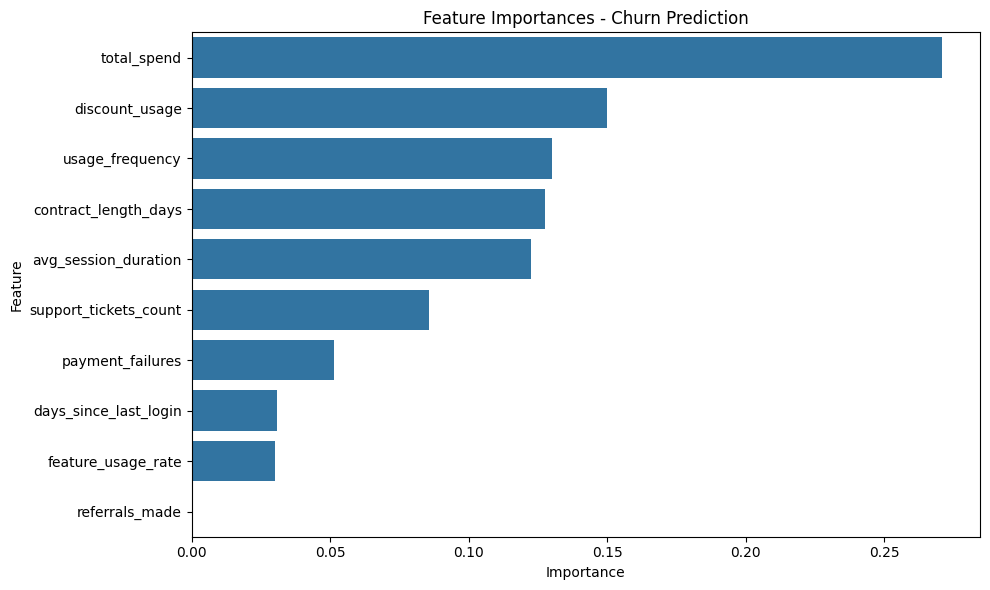

ROC AUC Score: 0.8410


: 

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%\n')

print('Classification Report:')
print(classification_report(y_test, y_pred))

# Feature Importance
feature_names = [
    'usage_frequency', 'days_since_last_login', 'support_tickets_count',
    'payment_failures', 'contract_length_days', 'feature_usage_rate',
    'avg_session_duration', 'total_spend', 'discount_usage', 'referrals_made'
]

importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances - Churn Prediction')
plt.tight_layout()
plt.show()

# ROC AUC calculation and plotting
y_prob = model.predict_proba(X_test_scaled)[:, 1]
auc_score = roc_auc_score(y_test, y_prob)
print(f'ROC AUC Score: {auc_score:.4f}')
